# Thesis figures

Figures are grouped by thesis chapter so the figure source is easier to find. The shared imports and paths are defined once at the top.


In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "Data").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find the Master_thesis repo root from the current working directory.")


REPO_ROOT = find_repo_root()
LATEX_DIR = REPO_ROOT.parent / "69c525a2d91967a989023aaf"
FIGURES_DIR = LATEX_DIR / "Figures"
IMAGES_DIR = LATEX_DIR / "Images"
LOCAL_FIGURES_DIR = REPO_ROOT / "figures"
DATA_DIR = REPO_ROOT / "Data"

for directory in (FIGURES_DIR, IMAGES_DIR, LOCAL_FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

print(f"Repo root: {REPO_ROOT}")
print(f"LaTeX figure directory: {FIGURES_DIR}")
print(f"LaTeX image directory: {IMAGES_DIR}")


Repo root: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
LaTeX figure directory: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\69c525a2d91967a989023aaf\Figures
LaTeX image directory: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\69c525a2d91967a989023aaf\Images


In [2]:
ISLAND_ID_TO_NAME = {
    "20": "Nes\u00f8y",
    "22": "Myken",
    "23": "Tr\u00e6na",
    "24": "Selv\u00e6r",
    "26": "Gjer\u00f8y",
    "27": "Hestmann\u00f8y",
    "28": "Indre Kvar\u00f8y",
    "33": "On\u00f8y og Lur\u00f8y",
    "34": "Lovund",
    "35": "Sleneset",
    "38": "Aldra",
    "60": "Leka",
    "61": "Vega",
    "63": "Vikna",
    "67": "Lauv\u00f8ya",
}


def style_axes(ax):
    ax.grid(True, alpha=0.25, linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def numeric_sort(values):
    return sorted(values, key=lambda value: int(value) if str(value).isdigit() else str(value))



## Methods

### AvgGRM-derived weighting schemes


(WindowsPath('C:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/weighting_schemes.pdf'),
 WindowsPath('C:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Figures/weighting_schemes.png'))

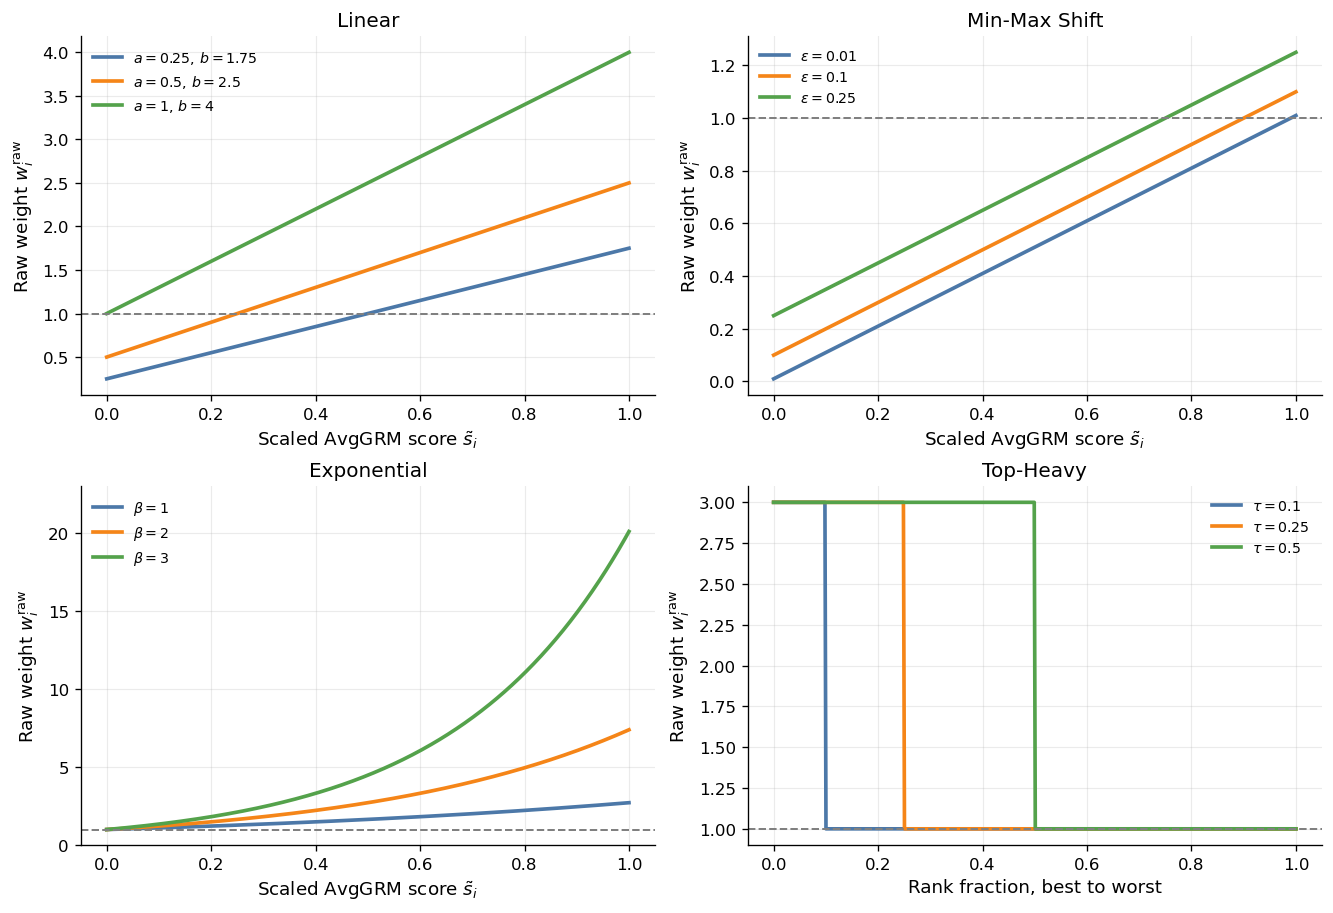

In [3]:
def plot_weighting_schemes(output_dir=FIGURES_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    colors = ["#4C78A8", "#F58518", "#54A24B"]
    score = np.linspace(0.0, 1.0, 500)
    rank_frac = np.linspace(0.0, 1.0, 500)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

    ax = axes[0, 0]
    linear_params = [(0.25, 1.75), (0.50, 2.50), (1.00, 4.00)]
    for color, (a, b) in zip(colors, linear_params):
        ax.plot(score, a + (b - a) * score, color=color, lw=2.2, label=fr"$a={a:g},\, b={b:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Linear")
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    ax = axes[0, 1]
    minmax_eps = [0.01, 0.10, 0.25]
    for color, eps in zip(colors, minmax_eps):
        ax.plot(score, eps + score, color=color, lw=2.2, label=fr"$\varepsilon={eps:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Min-Max Shift")
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    ax = axes[1, 0]
    exp_betas = [1.0, 2.0, 3.0]
    for color, beta in zip(colors, exp_betas):
        ax.plot(score, np.exp(beta * score), color=color, lw=2.2, label=fr"$\beta={beta:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_ylim(0, 23)
    ax.set_title("Exponential")
    ax.set_xlabel(r"Scaled AvgGRM score $\tilde{s}_i$")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    ax = axes[1, 1]
    top_fracs = [0.10, 0.25, 0.50]
    low = 1.0
    high = 3.0
    for color, tau in zip(colors, top_fracs):
        weights = np.where(rank_frac <= tau, high, low)
        ax.plot(rank_frac, weights, color=color, lw=2.2, label=fr"$\tau={tau:g}$")
    ax.axhline(1.0, color="0.5", lw=1.2, ls="--")
    ax.set_title("Top-Heavy")
    ax.set_xlabel("Rank fraction, best to worst")
    ax.set_ylabel(r"Raw weight $w_i^{\mathrm{raw}}$")
    ax.legend(frameon=False)
    style_axes(ax)

    for ax in axes.flat:
        ax.tick_params(labelsize=10)

    pdf_path = output_dir / "weighting_schemes.pdf"
    png_path = output_dir / "weighting_schemes.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    return fig, (pdf_path, png_path)


fig, weighting_paths = plot_weighting_schemes()
weighting_paths


## Results

### SNP PCA by island


(WindowsPath('C:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Images/pca_island_pairwise_1x3.pdf'),
 WindowsPath('C:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/69c525a2d91967a989023aaf/Images/pca_island_pairwise_1x3.png'))

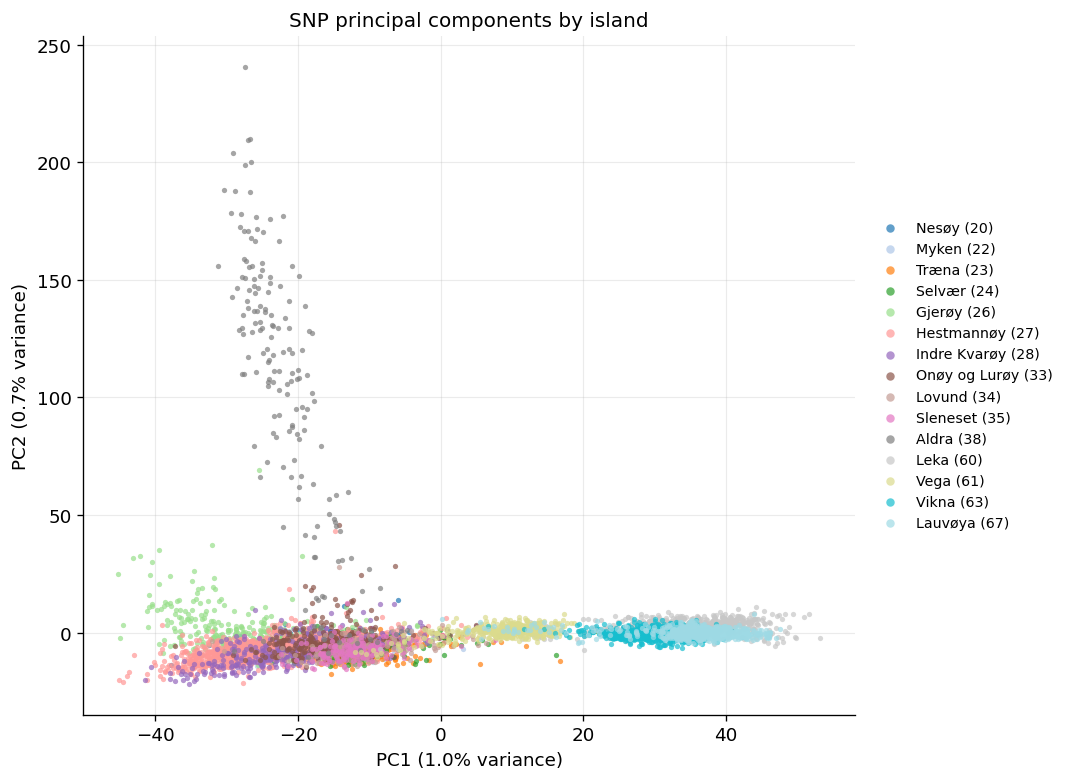

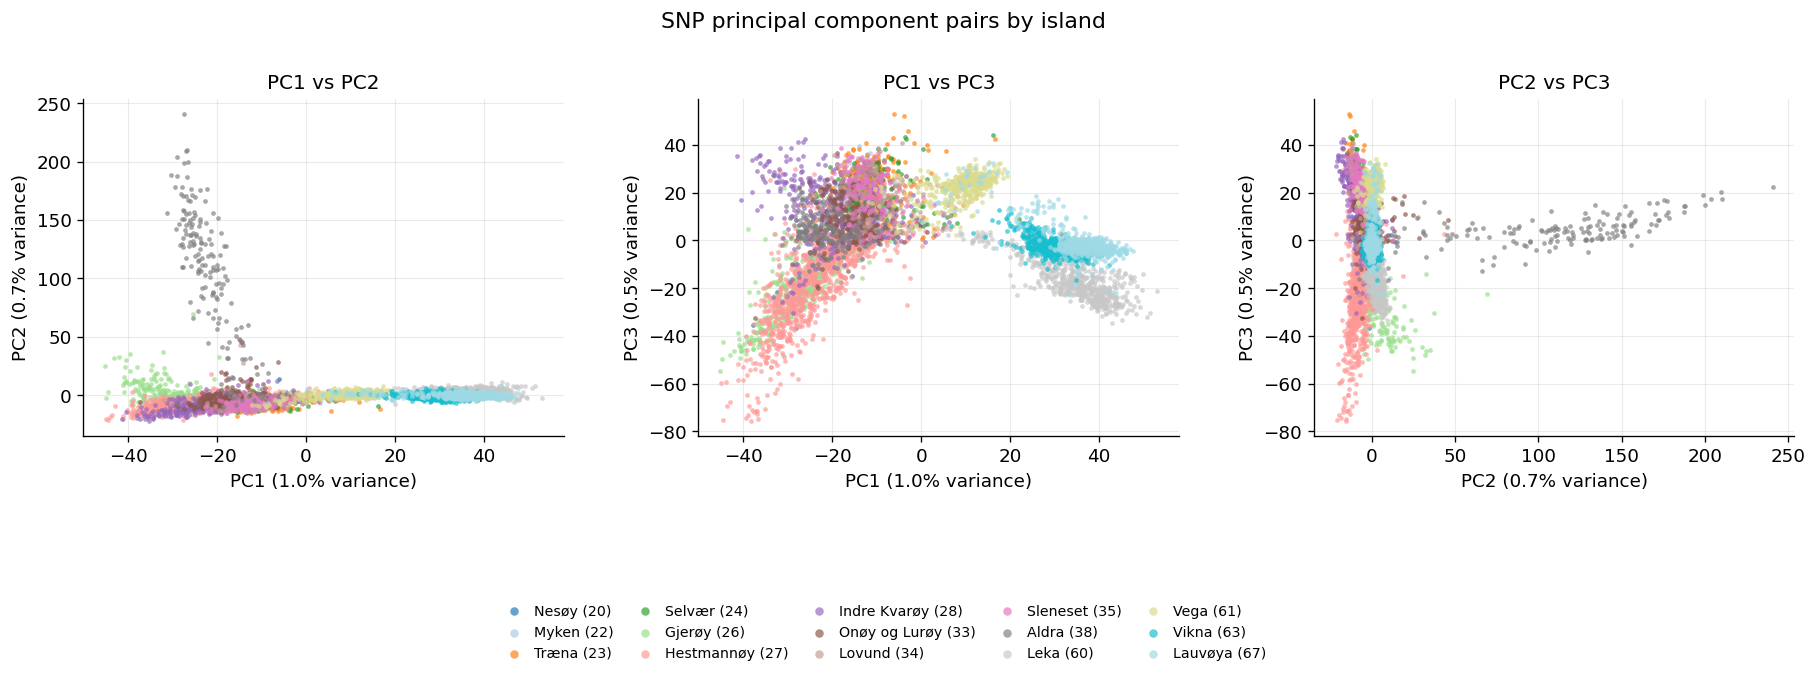

In [4]:
def load_snp_data_for_pca(npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz", min_count=20):
    data = np.load(npz_path, allow_pickle=False)
    X = data["snp"].astype(np.float32, copy=True)
    ids = data["ids"].astype(str)
    locality = data["locality"].astype(str)

    locality = np.where(locality == "68", "67", locality)
    counts = pd.Series(locality).value_counts()
    keep = counts[counts >= min_count].index.to_numpy()
    mask = np.isin(locality, keep)

    return X[mask], ids[mask], locality[mask]


def compute_snp_pca(X, n_components=2, standardize=True, max_snps=None, random_state=14):
    rng = np.random.default_rng(random_state)
    if max_snps is not None and max_snps < X.shape[1]:
        cols = np.sort(rng.choice(X.shape[1], size=int(max_snps), replace=False))
        X = X[:, cols]

    mean = X.mean(axis=0, dtype=np.float64).astype(np.float32)
    X = X - mean

    if standardize:
        std = X.std(axis=0, dtype=np.float64).astype(np.float32)
        std[std == 0] = 1.0
        X = X / std

    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=random_state)
    scores = pca.fit_transform(X)
    return scores, pca.explained_variance_ratio_


def plot_pca_by_island(
    npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz",
    output_dir=IMAGES_DIR,
    min_count=20,
    max_snps=None,
    random_state=14,
):
    X, ids, locality = load_snp_data_for_pca(npz_path=npz_path, min_count=min_count)
    scores, variance_ratio = compute_snp_pca(
        X,
        n_components=2,
        standardize=True,
        max_snps=max_snps,
        random_state=random_state,
    )

    df = pd.DataFrame(
        {
            "ringnr": ids,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "island_id": locality,
        }
    )
    df["island"] = df["island_id"].map(ISLAND_ID_TO_NAME).fillna(df["island_id"])

    order = numeric_sort(df["island_id"].unique())
    cmap = plt.get_cmap("tab20", len(order))

    fig, ax = plt.subplots(figsize=(8.8, 6.4), constrained_layout=True)
    for idx, island_id in enumerate(order):
        sub = df[df["island_id"] == island_id]
        label = f"{ISLAND_ID_TO_NAME.get(island_id, island_id)} ({island_id})"
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            s=10,
            alpha=0.70,
            linewidths=0,
            color=cmap(idx),
            label=label,
        )

    ax.set_xlabel(f"PC1 ({variance_ratio[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({variance_ratio[1] * 100:.1f}% variance)")
    ax.set_title("SNP principal components by island")
    style_axes(ax)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        ncol=1,
        markerscale=1.6,
        borderaxespad=0.0,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "pca_island_pc1_pc2.pdf"
    png_path = output_dir / "pca_island_pc1_pc2.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    return fig, df, variance_ratio, (pdf_path, png_path)


fig, pca_scores, pca_variance_ratio, pca_paths = plot_pca_by_island()
pca_paths


def plot_pca_pairwise_by_island(
    npz_path=DATA_DIR / "npz" / "snp_body_mass_ALL.npz",
    output_dir=IMAGES_DIR,
    min_count=20,
    max_snps=None,
    random_state=14,
):
    X, ids, locality = load_snp_data_for_pca(npz_path=npz_path, min_count=min_count)
    scores, variance_ratio = compute_snp_pca(
        X,
        n_components=3,
        standardize=True,
        max_snps=max_snps,
        random_state=random_state,
    )

    df = pd.DataFrame(
        {
            "ringnr": ids,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "PC3": scores[:, 2],
            "island_id": locality,
        }
    )
    df["island"] = df["island_id"].map(ISLAND_ID_TO_NAME).fillna(df["island_id"])

    order = numeric_sort(df["island_id"].unique())
    cmap = plt.get_cmap("tab20", len(order))
    pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2), constrained_layout=False)
    handles = []
    labels = []

    for ax, (x_col, y_col) in zip(axes, pairs):
        for idx, island_id in enumerate(order):
            sub = df[df["island_id"] == island_id]
            label = f"{ISLAND_ID_TO_NAME.get(island_id, island_id)} ({island_id})"
            scatter = ax.scatter(
                sub[x_col],
                sub[y_col],
                s=8,
                alpha=0.68,
                linewidths=0,
                color=cmap(idx),
                label=label,
            )
            if ax is axes[0]:
                handles.append(scatter)
                labels.append(label)

        x_idx = int(x_col[-1]) - 1
        y_idx = int(y_col[-1]) - 1
        ax.set_xlabel(f"{x_col} ({variance_ratio[x_idx] * 100:.1f}% variance)")
        ax.set_ylabel(f"{y_col} ({variance_ratio[y_idx] * 100:.1f}% variance)")
        ax.set_title(f"{x_col} vs {y_col}")
        style_axes(ax)

    fig.suptitle("SNP principal component pairs by island", y=0.98)
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
        ncol=5,
        markerscale=1.8,
        columnspacing=1.2,
        handletextpad=0.4,
    )
    fig.subplots_adjust(left=0.07, right=0.99, top=0.84, bottom=0.30, wspace=0.28)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "pca_island_pairwise_1x3.pdf"
    png_path = output_dir / "pca_island_pairwise_1x3.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    return fig, df, variance_ratio, (pdf_path, png_path)


fig, pca_pairwise_scores, pca_pairwise_variance_ratio, pca_pairwise_paths = plot_pca_pairwise_by_island()
pca_pairwise_paths

